# 02 - ML Pipeline Multiclass

Full model selection and fine-tuning, OOD evaluation, and interpretability
for WoT and Dota at 3-class granularity — chosen in 01_granularity_experiment.ipynb.

In [2]:
# imports
import warnings, json
from pathlib import Path
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from optuna.samplers import TPESampler
import joblib

import sys
sys.path.insert(0, str(Path('../..')))
from src.tokenizer import tokenize
from src.scoring import cv_score, holdout_score, ood_score, make_f1_scorer

# project root and data paths
PROJECT_ROOT = Path().resolve().parents[1]
DATA_WOT     = PROJECT_ROOT / 'data/processed_data/wot'
DATA_DOTA    = PROJECT_ROOT / 'data/processed_data/dota'

# split name -> parquet filename
_SPLIT = {'train': 'x_train.parquet', 'val': 'x_validation.parquet'}

# data loaders — replacing src.loaders
def load_wot(split): return pd.read_parquet(DATA_WOT  / _SPLIT[split])
def load_dota(split): return pd.read_parquet(DATA_DOTA / _SPLIT[split])
def load_combined(split): return pd.concat([load_wot(split), load_dota(split)], ignore_index=True)

# TF-IDF config — consistent with cleaning pipeline
TFIDF_KWARGS = dict(
    ngram_range=(1, 2), min_df=1, max_df=0.95,
    sublinear_tf=True, norm='l2',
    analyzer='word', tokenizer=tokenize, token_pattern=None,
)

# pipeline builder — replacing src.pipelines.build_pipe
def build_pipe(clf, oversampler=None):
    steps = [('tfidf', TfidfVectorizer(**TFIDF_KWARGS))]
    if oversampler is not None:
        steps.append(('oversample', oversampler))
    steps.append(('clf', clf))
    return ImbPipeline(steps)

# reproducibility and run config
seed = 7524
OPTUNA_TRIALS = 50
MODELS_DIR = PROJECT_ROOT / 'models'

np.random.seed(seed)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
MODELS_DIR.mkdir(exist_ok=True)

# best granularity from notebook 01
wot_best_n  = 3
dota_best_n = 3

# label schemes — 3-class: 0=Non-Toxic, 1=Mild, 2=Severe
WOT_SCHEME_3  = {0: 0, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2}
DOTA_SCHEME_3 = {0: 0, 1: 2, 2: 2, 3: 1}

# combined loader — applies per-game scheme before concat
def load_combined_3class(split):
    wot  = load_wot(split).copy();  wot['label']  = wot['label'].astype(int).map(WOT_SCHEME_3)
    dota = load_dota(split).copy(); dota['label'] = dota['label'].astype(int).map(DOTA_SCHEME_3)
    return pd.concat([wot, dota], ignore_index=True)

# class name maps for plots and reports
WOT_CLASS_NAMES = {
    3: ['Non-Toxic', 'Mild Toxicity', 'Severe Toxicity'],
}

DOTA_CLASS_NAMES = {
    3: ['Non-Toxic', 'Mild Toxicity', 'Severe Toxicity'],
}

**World of Tanks**
| Class | Terminology |
|---|---|
| 0 | Non-Toxic |
| 1 | Insults and Flaming |
| 2 | Other Offensive Texts |
| 3 | Hate and Harassment |
| 4 | Threats |
| 5 | Extremism |

**Dota**
| Class | Label |
|---|---|
| 0 | Other (non-toxic) |
| 1 | Ego |
| 2 | Aggression |
| 3 | Impolite |


## Section 2: Model Selection

In [9]:
# model selection with Optuna tuning
# 50 Optuna trials = 50 sampled hyperparameter configurations
# each trial is evaluated with cross-validation on macro F1
# Optuna runs sequentially; CV can use all cores

def _macro_f1_cv(pipe, X_train, y_train):
    # macro F1 because this is multiclass classification
    return cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=make_f1_scorer(len(pd.Series(y_train).unique())),
        n_jobs=-1
    ).mean()


def _build_lr_from_trial(trial):
    # only multiclass-safe solvers
    solver = trial.suggest_categorical('clf__solver', ['lbfgs', 'newton-cg', 'saga'])
    C = trial.suggest_float('clf__C', 1e-2, 20.0, log=True)
    tol = trial.suggest_float('clf__tol', 1e-5, 1e-2, log=True)
    fit_intercept = trial.suggest_categorical('clf__fit_intercept', [True, False])

    # penalty depends on solver compatibility
    penalty = (
        'l2'
        if solver in ['lbfgs', 'newton-cg']
        else trial.suggest_categorical('clf__penalty', ['l1', 'l2'])
    )

    return LogisticRegression(
        C=C,
        solver=solver,
        penalty=penalty,
        tol=tol,
        fit_intercept=fit_intercept,
        max_iter=2000,
        random_state=seed,
        class_weight='balanced',
        n_jobs=1 if solver == 'saga' else None,
    )


def _build_svc_from_trial(trial):
    # focus on the combinations that matter and are valid
    loss = trial.suggest_categorical('clf__loss', ['hinge', 'squared_hinge'])
    C = trial.suggest_float('clf__C', 1e-2, 20.0, log=True)
    tol = trial.suggest_float('clf__tol', 1e-5, 1e-2, log=True)
    fit_intercept = trial.suggest_categorical('clf__fit_intercept', [True, False])

    # hinge requires dual=True; squared_hinge can use either
    dual = True if loss == 'hinge' else trial.suggest_categorical('clf__dual', [True, False])

    return LinearSVC(
        C=C,
        loss=loss,
        dual=dual,
        tol=tol,
        fit_intercept=fit_intercept,
        max_iter=2000,
        random_state=seed,
        class_weight='balanced',
    )


def _run_optuna_search(game, model_name, model_builder, X_train, y_train):
    print(f'[{game}] {model_name} (Optuna) - {OPTUNA_TRIALS} trials ...')

    def objective(trial):
        # build a fresh pipeline for each sampled trial
        pipe = build_pipe(model_builder(trial), oversampler=None)
        return _macro_f1_cv(pipe, X_train, y_train)

    def _trial_callback(study, trial):
        # print only the current trial summary
        marker = ' *' if trial.number == study.best_trial.number else ''
        params_str = ', '.join(f"{k.split('__')[-1]}={v}" for k, v in trial.params.items())
        print(f'  [{trial.number + 1:>2}/{OPTUNA_TRIALS}]  {params_str}  f1={trial.value:.4f}{marker}')

    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=seed)
    )
    study.optimize(
        objective,
        n_trials=OPTUNA_TRIALS,
        callbacks=[_trial_callback],
        show_progress_bar=True
    )

    print(f'  -> best params={study.best_params}  f1={study.best_value:.4f}')

    # rebuild the best pipeline from the winning trial
    best_pipe = build_pipe(model_builder(study.best_trial), oversampler=None)
    best_scores = cv_score(best_pipe, X_train, y_train, cv=cv)

    return best_pipe, best_scores, study


def run_model_selection(game: str, load_fn, scheme: dict | None = None):
    # apply label scheme; None means labels are already mapped
    train_df = load_fn('train').copy()
    if scheme is not None:
        train_df['label'] = train_df['label'].astype(int).map(scheme)

    # features and labels
    X_train = train_df['message']
    y_train = train_df['label']

    models_comparison = []
    studies = {}

    # Logistic Regression — Optuna tunes regularisation + solver behaviour
    lr_pipe, lr_scores, lr_study = _run_optuna_search(
        game, 'Logistic Regression', _build_lr_from_trial, X_train, y_train
    )
    models_comparison.append({'Model': 'Logistic Regression', **lr_scores})
    studies['Logistic Regression'] = lr_study

    # LinearSVC — Optuna tunes regularisation + margin solver behaviour
    svc_pipe, svc_scores, svc_study = _run_optuna_search(
        game, 'LinearSVC', _build_svc_from_trial, X_train, y_train
    )
    models_comparison.append({'Model': 'LinearSVC', **svc_scores})
    studies['LinearSVC'] = svc_study

    compare_df = (
        pd.DataFrame(models_comparison)
        .sort_values('cv_f1', ascending=False)
        .reset_index(drop=True)
    )

    print(f'\n{game} results:')
    for _, row in compare_df.iterrows():
        print(
            f"  {row['Model']:<25}  F1={row['cv_f1']:.4f} ±{row['cv_f1_std']:.4f}"
            f"  Recall={row['cv_recall']:.4f}  Precision={row['cv_precision']:.4f}"
        )

    pipes = {
        'Logistic Regression': lr_pipe,
        'LinearSVC': svc_pipe,
    }
    return compare_df, pipes, studies


# best model selection for world of tanks dataset
print('=== WoT model selection ===')
wot_compare_df, wot_pipes, wot_studies = run_model_selection('WoT', load_wot, WOT_SCHEME_3)

# best model selection for dota dataset
print('\n=== Dota model selection ===')
dota_compare_df, dota_pipes, dota_studies = run_model_selection('Dota', load_dota, DOTA_SCHEME_3)

wot_best_model_name = wot_compare_df.iloc[0]['Model']
dota_best_model_name = dota_compare_df.iloc[0]['Model']
print(f'\nBest: WoT={wot_best_model_name}, Dota={dota_best_model_name}')

=== WoT model selection ===
[WoT] Logistic Regression (Optuna) - 50 trials ...


  0%|          | 0/50 [00:00<?, ?it/s]

  [ 1/50]  solver=saga, C=0.023782084460027744, tol=0.004225527207190311, fit_intercept=False, penalty=l1  f1=0.5524 *
  [ 2/50]  solver=newton-cg, C=0.013204902347993213, tol=0.0002045184669277881, fit_intercept=True  f1=0.6696 *
  [ 3/50]  solver=newton-cg, C=0.010783421319909378, tol=0.001126202647115956, fit_intercept=True  f1=0.6649
  [ 4/50]  solver=saga, C=0.013700788552124527, tol=0.00012891649159136305, fit_intercept=True, penalty=l1  f1=0.1967
  [ 5/50]  solver=saga, C=0.09686115680990609, tol=9.084508579841047e-05, fit_intercept=True, penalty=l2  f1=0.5041
  [ 6/50]  solver=newton-cg, C=0.08530587646022501, tol=3.6592031194784106e-05, fit_intercept=False  f1=0.6567
  [ 7/50]  solver=newton-cg, C=0.09478023262442258, tol=0.00035932147966983126, fit_intercept=False  f1=0.6574
  [ 8/50]  solver=saga, C=0.21109177298212853, tol=0.0011894652761041307, fit_intercept=False, penalty=l1  f1=0.6274
  [ 9/50]  solver=saga, C=0.44938994071753774, tol=0.0003753212733438789, fit_intercept

  0%|          | 0/50 [00:00<?, ?it/s]

  [ 1/50]  loss=squared_hinge, C=2.206348934487919, tol=2.1975494341194843e-05, fit_intercept=True, dual=True  f1=0.7398 *
  [ 2/50]  loss=hinge, C=5.561907164161451, tol=0.0013826534026733321, fit_intercept=False  f1=0.7372
  [ 3/50]  loss=hinge, C=1.1948658302363075, tol=0.0062909624233258975, fit_intercept=True  f1=0.7458 *
  [ 4/50]  loss=squared_hinge, C=0.10395236453529981, tol=0.000494407675904373, fit_intercept=False, dual=False  f1=0.7253
  [ 5/50]  loss=hinge, C=9.79771321163768, tol=0.0003987676320279228, fit_intercept=True  f1=0.7492 *
  [ 6/50]  loss=hinge, C=0.11336019878531085, tol=0.002652191858059427, fit_intercept=True  f1=0.6828
  [ 7/50]  loss=squared_hinge, C=13.285201463073726, tol=0.0012090430913421174, fit_intercept=True, dual=False  f1=0.7386
  [ 8/50]  loss=squared_hinge, C=0.2418070869211729, tol=7.720549166975152e-05, fit_intercept=True, dual=True  f1=0.7398
  [ 9/50]  loss=squared_hinge, C=0.21109177298212853, tol=0.0011894652761041307, fit_intercept=False,

  0%|          | 0/50 [00:00<?, ?it/s]

  [ 1/50]  solver=saga, C=0.023782084460027744, tol=0.004225527207190311, fit_intercept=False, penalty=l1  f1=0.7732 *
  [ 2/50]  solver=newton-cg, C=0.013204902347993213, tol=0.0002045184669277881, fit_intercept=True  f1=0.8134 *
  [ 3/50]  solver=newton-cg, C=0.010783421319909378, tol=0.001126202647115956, fit_intercept=True  f1=0.8086
  [ 4/50]  solver=saga, C=0.013700788552124527, tol=0.00012891649159136305, fit_intercept=True, penalty=l1  f1=0.7388
  [ 5/50]  solver=saga, C=0.09686115680990609, tol=9.084508579841047e-05, fit_intercept=True, penalty=l2  f1=0.8491 *
  [ 6/50]  solver=newton-cg, C=0.08530587646022501, tol=3.6592031194784106e-05, fit_intercept=False  f1=0.7822
  [ 7/50]  solver=newton-cg, C=0.09478023262442258, tol=0.00035932147966983126, fit_intercept=False  f1=0.7845
  [ 8/50]  solver=saga, C=0.21109177298212853, tol=0.0011894652761041307, fit_intercept=False, penalty=l1  f1=0.8001
  [ 9/50]  solver=saga, C=0.44938994071753774, tol=0.0003753212733438789, fit_interce

  0%|          | 0/50 [00:00<?, ?it/s]

  [ 1/50]  loss=squared_hinge, C=2.206348934487919, tol=2.1975494341194843e-05, fit_intercept=True, dual=True  f1=0.8800 *
  [ 2/50]  loss=hinge, C=5.561907164161451, tol=0.0013826534026733321, fit_intercept=False  f1=0.8625
  [ 3/50]  loss=hinge, C=1.1948658302363075, tol=0.0062909624233258975, fit_intercept=True  f1=0.8849 *
  [ 4/50]  loss=squared_hinge, C=0.10395236453529981, tol=0.000494407675904373, fit_intercept=False, dual=False  f1=0.8536
  [ 5/50]  loss=hinge, C=9.79771321163768, tol=0.0003987676320279228, fit_intercept=True  f1=0.8735
  [ 6/50]  loss=hinge, C=0.11336019878531085, tol=0.002652191858059427, fit_intercept=True  f1=0.8456
  [ 7/50]  loss=squared_hinge, C=13.285201463073726, tol=0.0012090430913421174, fit_intercept=True, dual=False  f1=0.8719
  [ 8/50]  loss=squared_hinge, C=0.2418070869211729, tol=7.720549166975152e-05, fit_intercept=True, dual=True  f1=0.8826
  [ 9/50]  loss=squared_hinge, C=0.21109177298212853, tol=0.0011894652761041307, fit_intercept=False, d

In [10]:
import joblib
MODELS_DIR = Path('../../models')
MODELS_DIR.mkdir(exist_ok=True)

# save best models with metadata for later use in evaluation and inference
joblib.dump(
    {
        'pipeline': wot_pipes[wot_best_model_name],
        'model_name': wot_best_model_name,
        'cv_row': wot_compare_df.iloc[0].to_dict(),
        'game': 'WoT',
        'label_scheme': WOT_SCHEME_3,
        'seed': seed,
    },
    MODELS_DIR / 'wot_best_multiclass.joblib'
)

joblib.dump(
    {
        'pipeline': dota_pipes[dota_best_model_name],
        'model_name': dota_best_model_name,
        'cv_row': dota_compare_df.iloc[0].to_dict(),
        'game': 'Dota',
        'label_scheme': DOTA_SCHEME_3,
        'seed': seed,
    },
    MODELS_DIR / 'dota_best_multiclass.joblib'
)

print('Saved best WoT and Dota models.')

Saved best WoT and Dota models.


In [12]:
# load and print the saved models to verify
wot_best_artifact = joblib.load('../../models/wot_best_multiclass.joblib')
dota_best_artifact = joblib.load('../../models/dota_best_multiclass.joblib')

wot_best_pipe = wot_best_artifact['pipeline']
dota_best_pipe = dota_best_artifact['pipeline']
# model name
print(f"\nLoaded WoT best model: {wot_best_artifact['model_name']}")
# parameters and CV scores
print(f"WoT CV scores: {wot_best_artifact['cv_row']}")
print(f"Loaded Dota best model: {dota_best_artifact['model_name']}")
# parameters and CV scores
print(f"Dota CV scores: {dota_best_artifact['cv_row']}")


Loaded WoT best model: LinearSVC
WoT CV scores: {'Model': 'LinearSVC', 'cv_f1': 0.7529, 'cv_f1_std': 0.009, 'cv_recall': 0.7097, 'cv_precision': 0.8366}
Loaded Dota best model: LinearSVC
Dota CV scores: {'Model': 'LinearSVC', 'cv_f1': 0.8854, 'cv_f1_std': 0.0059, 'cv_recall': 0.8737, 'cv_precision': 0.9001}


## Section 2: Evaluate Best Model + OOD at Binary Level

In [13]:
# evaluate best model on holdout set and OOD
# OOD always at binary level - both games share toxic/non-toxic contract

def evaluate_best(game, best_name, pipes, load_fn, n_classes, class_names,
                  compare_df, scheme=None, ood_load_fn=None, ood_game=None, ood_scheme=None):
    # apply label scheme — None means labels already mapped
    train_df = load_fn('train').copy()
    if scheme is not None:
        train_df['label'] = train_df['label'].astype(int).map(scheme)

    val_df = load_fn('val').copy()
    if scheme is not None:
        val_df['label'] = val_df['label'].astype(int).map(scheme)

    # features and targets
    X_train, y_train = train_df['message'], train_df['label']
    X_val, y_val = val_df['message'], val_df['label']

    # pipeline with best model 
    pipe = pipes[best_name]

    # compute scores on test data 
    scores = holdout_score(pipe, X_train, y_train, X_val, y_val)

    print(f'=== {game} {best_name} - in-game test ===')
    print(classification_report(y_val, pipe.predict(X_val), target_names=class_names, zero_division=0))

    # OOD: binarise the other game's labels and evaluate
    ood_scores = {}
    if ood_load_fn:
        # validation data out of sample 
        ood_val = ood_load_fn('val').copy()
        _ood_scheme = ood_scheme or scheme
        if _ood_scheme is not None:
            ood_val['label'] = ood_val['label'].astype(int).map(_ood_scheme)

        # OOD features and targets
        X_ood, y_ood = ood_val['message'], ood_val['label']

        # compute OOD scores
        ood_scores = ood_score(pipe, X_ood, y_ood)
        print(f'=== {game} - {ood_game} OOD ===')
        print(classification_report(y_ood, pipe.predict(X_ood),
                                    target_names=class_names, zero_division=0))

    # pull cv scores from the comparison table for the best model
    best_cv = compare_df[compare_df['Model'] == best_name].iloc[0]

    # append_registry({
    #     'experiment': 'ml_pipeline_multiclass',
    #     'train_game': game,
    #     'test_game': game,
    #     'n_classes': n_classes,
    #     'label_scheme': 'binary',
    #     'model': best_name,
    #     'cv_f2': best_cv.get('cv_f2'),
    #     'cv_f2_std': best_cv.get('cv_f2_std'),
    #     'cv_recall': best_cv.get('cv_recall'),
    #     'cv_precision': best_cv.get('cv_precision'),
    #     **scores,
    #     'ood_f2': ood_scores.get('ood_f2'),
    #     'ood_recall': ood_scores.get('ood_recall'),
    #     'ood_precision': ood_scores.get('ood_precision'),
    #     'ood_auc': ood_scores.get('ood_auc'),
    #     'anomaly_auroc': None,
    #     'notes': f'best_n={n_classes}',
    # }, path=CONFIG['registry_path'])

    return pipe


print('=== WoT ===')
wot_best_pipe = evaluate_best(
    'WoT', wot_best_model_name, wot_pipes, load_wot,
    wot_best_n, WOT_CLASS_NAMES[wot_best_n], wot_compare_df,
    scheme=WOT_SCHEME_3, ood_load_fn=load_dota, ood_game='Dota', ood_scheme=DOTA_SCHEME_3
)

print('\n=== Dota ===')
dota_best_pipe = evaluate_best(
    'Dota', dota_best_model_name, dota_pipes, load_dota,
    dota_best_n, DOTA_CLASS_NAMES[dota_best_n], dota_compare_df,
    scheme=DOTA_SCHEME_3, ood_load_fn=load_wot, ood_game='WoT', ood_scheme=WOT_SCHEME_3
)

=== WoT ===
=== WoT LinearSVC - in-game test ===
                 precision    recall  f1-score   support

      Non-Toxic       0.94      0.95      0.94      8050
  Mild Toxicity       0.75      0.72      0.74      1780
Severe Toxicity       0.42      0.41      0.41        69

       accuracy                           0.90      9899
      macro avg       0.70      0.69      0.70      9899
   weighted avg       0.90      0.90      0.90      9899

=== WoT - Dota OOD ===
                 precision    recall  f1-score   support

      Non-Toxic       0.83      0.92      0.88      5301
  Mild Toxicity       0.04      0.12      0.06       452
Severe Toxicity       0.55      0.02      0.04      1404

       accuracy                           0.70      7157
      macro avg       0.47      0.35      0.33      7157
   weighted avg       0.73      0.70      0.66      7157


=== Dota ===
=== Dota LinearSVC - in-game test ===
                 precision    recall  f1-score   support

      Non-Toxi

## Section 4: Interpretability - Top TF-IDF Features per Class

(3, 30167)


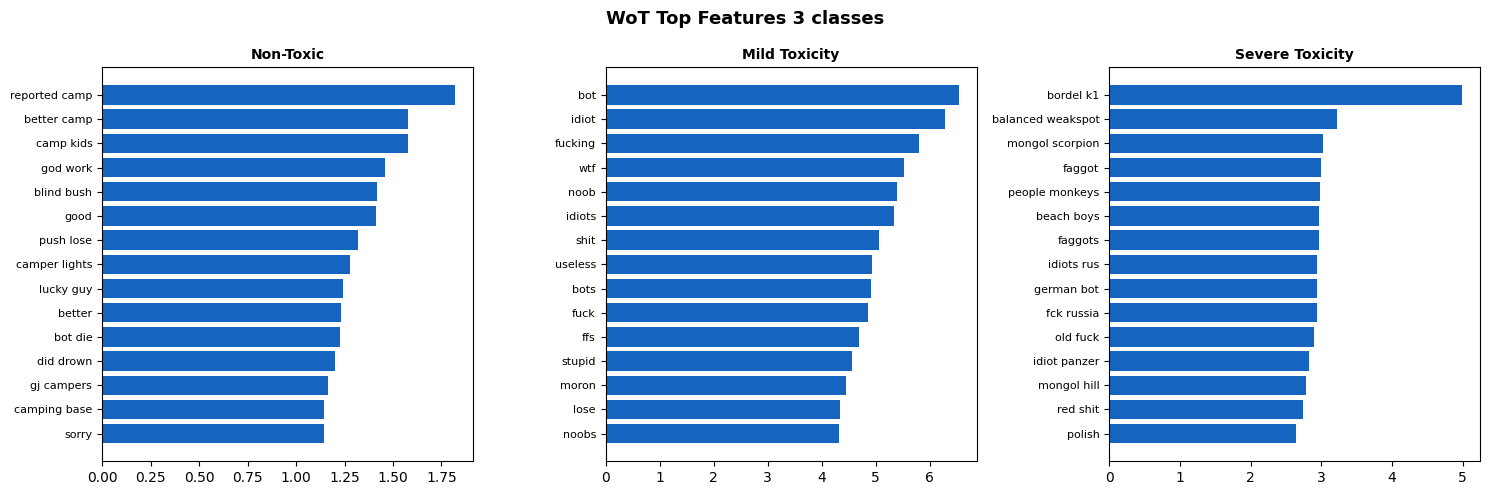

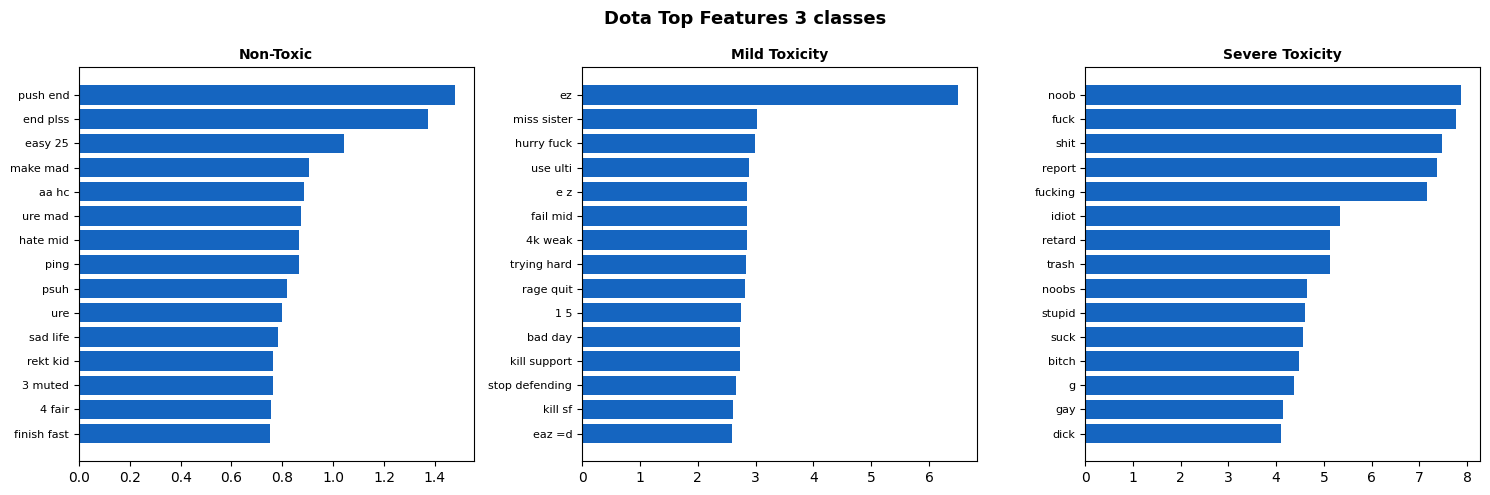

In [14]:
# fit 
train_df = load_wot('train').copy()
train_df['label'] = train_df['label'].astype(int).map(WOT_SCHEME_3)
X_tr = train_df['message']
y_tr = train_df['label']

wot_best_pipe.fit(X_tr, y_tr)
print(wot_best_pipe.named_steps['clf'].coef_.shape)

def plot_top_features(pipe, class_names: list, title: str, top_n: int = 15):
    from matplotlib.patches import Patch

    tfidf = pipe.named_steps['tfidf']
    clf   = pipe.named_steps['clf']

    # word TF-IDF only — no char n-gram features
    raw_names = np.array(tfidf.get_feature_names_out())

    coef = clf.coef_ if hasattr(clf, 'coef_') else clf.feature_log_prob_
    if coef.shape[0] == 1:
        coef = np.vstack([-coef, coef])

    n_cls = len(class_names)
    fig, axes = plt.subplots(1, n_cls, figsize=(5 * n_cls, 5))
    if n_cls == 1:
        axes = [axes]

    for ax, cls_idx, cls_name in zip(axes, range(n_cls), class_names):
        top_idx = np.argsort(coef[cls_idx])[-top_n:][::-1]
        ax.barh(raw_names[top_idx][::-1], coef[cls_idx][top_idx][::-1], color='#1565C0')
        ax.set_title(cls_name, fontsize=10, fontweight='bold')
        ax.tick_params(axis='y', labelsize=8)



    plt.suptitle(title, fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()



# plot the features 
plot_top_features(wot_best_pipe,  WOT_CLASS_NAMES[wot_best_n],
                  f'WoT Top Features {wot_best_n} classes')
plot_top_features(dota_best_pipe, DOTA_CLASS_NAMES[dota_best_n],
                  f'Dota Top Features {dota_best_n} classes')


## Section 5: Combined Testing

In [ ]:
# combined data fine-tuning 
print('\n=== Combined model selection ===')
combined_compare_df, combined_pipes = run_model_selection('Combined', load_combined_3class, 3)

combined_best_model_name = combined_compare_df.iloc[0]['Model']
print(f'\nBest: Combined={combined_best_model_name}')


=== Combined model selection ===


TypeError: 'int' object is not callable

In [16]:
# fit once on combined train, evaluate on combined val
combined_best_pipe = evaluate_best(
    'Combined', combined_best_model_name, combined_pipes, load_combined_3class,
    3, ['Non-Toxic', 'Mild', 'Severe'], combined_compare_df,
    scheme=None, ood_load_fn=None
)

# evaluate already-fitted pipe on each game val — no refit
def load_val_3class(load_fn, scheme):
    df = load_fn('val').copy()
    df['label'] = df['label'].astype(int).map(scheme)
    return df['message'], df['label']

# world of tanks 
X_wot_val,  y_wot_val  = load_val_3class(load_wot,  WOT_SCHEME_3)

# dota
X_dota_val, y_dota_val = load_val_3class(load_dota, DOTA_SCHEME_3)

# combined dataset predictions on world of tanks
print('\n=== Combined -> WoT ===')
print(classification_report(y_wot_val,  combined_best_pipe.predict(X_wot_val),
                             target_names=['Non-Toxic', 'Mild', 'Severe'], zero_division=0))

# combined dataset predictions on dota
print('\n=== Combined -> Dota ===')
print(classification_report(y_dota_val, combined_best_pipe.predict(X_dota_val),
                             target_names=['Non-Toxic', 'Mild', 'Severe'], zero_division=0))


NameError: name 'combined_best_model_name' is not defined